In [1]:
# Linalg
import jax.numpy as np
import flax.linen as nn
import jax
import numpy as onp

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Helper libraries
from dataclasses import dataclass
import h5py as hf

# Symbolic regression
from pysr import PySRRegressor

## Analysis Functions

In [2]:
vision_sizes = [2] #[1, 2, 3, 4, 5]

In [3]:
@dataclass
class Measurement:
    data: np.ndarray
    uncertainty: np.ndarray

In [4]:
def transform_coordinates(position_data: np.ndarray, reference_data: np.ndarray):
    """
    Move colloids in all frames back into a single reference frame.
    Required for RDF calculation.
    
    Parameters
    ----------
    position_data : np.ndarray (time_steps, colloids, 3)
            Colloid data to transform.
    reference_data : np.ndarray (time_steps, colloids, 3)
            Rod data acting as reference.
    """
    # Convert to polar coordinates
    def inner_fn(
        position: np.ndarray, reference
    ):
        origin = np.array([500., 500., 0.])
        distance_vector = position - origin
        distance = np.linalg.norm(distance_vector)
        normed_distance = distance_vector / distance
        
        angle = np.arctan2(
            normed_distance[0] * reference[1] - normed_distance[1] * reference[0],
            normed_distance[0] * reference[0] + normed_distance[1] * reference[1]
        )
        return np.array([distance, angle])
    
    mapped_fn = jax.vmap(inner_fn, in_axes=(0, None))
    
    outer_map_fn = jax.vmap(mapped_fn, in_axes=(0, 0))
    
    polar_coordinates = outer_map_fn(
        position_data, reference_data
    )
    
    # Convert to cartesian coordinates
    def inner_fn(
        distance: np.ndarray, angle: np.ndarray
    ):
        x = distance * np.cos(angle)
        y = distance * np.sin(angle)
        
        return jnp.array([x, y])
    
    mapped_fn = jax.vmap(inner_fn, in_axes=(0, 0))
    
    outer_map_fn = jax.vmap(mapped_fn, in_axes=(0, 0))
    
    cartesian_coords = outer_map_fn(
        polar_coordinates[:, :, 0], polar_coordinates[:, :, 1]
    )
        
    return cartesian_coords  

In [5]:
def compute_rod_velocity(data: np.ndarray):
    """
    Compute rod velocity.
    
    Parameters
    ----------
    data : np.ndarray (time_steps, 1, 3)
    """
#     x = np.linspace(0, data.shape[0], data.shape[0] - 1) * 2
    reference = data[0]
    angles = []
    
    for item in data[1:]:
        angles.append(
            np.arctan2(
                item[0] * reference[1] - item[1] * reference[0],
                item[0] * reference[0] + item[1] * reference[1]
            )
        )
    
    return np.gradient(np.array(angles))

In [6]:
def load_data(embedding_dimension: int, ensemble: int):
    """
    Load data from the hdf5 database.
    
    Parameters
    ----------
    embedding_dimension : int
            Which directory to load from.
    ensemble : int
            Which ensemble to load
    """
    root_path = f"{embedding_dimension}_dimensions/{ensemble}"
    with hf.File(
        f"{root_path}/deployment/trajectory.hdf5",
        "r"
    ) as db:
        colloid_data = db["colloids"]["Unwrapped_Positions"][:, :20, :]
        rod_data = db["colloids"]["Directors"][:, 25, :]
        
    exploration_rewards = np.load(
        f"{root_path}/exploration.npy", allow_pickle=True
    )
    no_exploration_rewards = np.load(
        f"{root_path}/no-exploration.npy", allow_pickle=True
    )
        
    return colloid_data, rod_data, exploration_rewards, no_exploration_rewards

## Training Success

* Plot probability of success by vision
* Compare reward curves

In [7]:
# Success probability
probabilities = {}
for vision in vision_sizes:

    successes = 0
    for i in range(1, 21, 1):
        _, rod_data, _, _ = load_data(vision, i)
        velocity = compute_rod_velocity(rod_data)
        if max(abs(velocity)) > 2:
            successes += 1

    probabilities[vision] = successes / 20


In [8]:
reward_data = {}
for vision in vision_sizes:
    
    total_rewards = []
    for i in range(1, 21, 1):
        _, rod_data, exp_r, no_exp_r = load_data(vision, i)
        velocity = compute_rod_velocity(rod_data)
        if max(abs(velocity)) > 2:
            total_rewards.append(exp_r.sum() + no_exp_r.sum())
            
    reward_data[vision] = Measurement(
        data = np.mean(np.array(total_rewards)) / 10000, 
        uncertainty=np.std(np.array(total_rewards)) / 1000
    )     


Text(0, 0.5, 'Reward per episode')

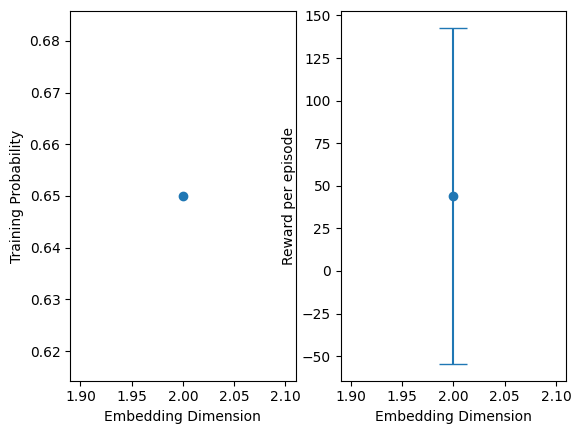

In [9]:
fig, ax = plt.subplots(1, 2)

ax[0].plot(
    vision_sizes, 
    [probabilities[item] for item in vision_sizes],
    "o"
)
ax[1].errorbar(
    vision_sizes, 
    [reward_data[item].data for item in vision_sizes],
    yerr=[reward_data[item].uncertainty for item in vision_sizes],
    marker="o",
    ls="none",
    capsize=10,
)

ax[0].set_xlabel("Embedding Dimension")
ax[1].set_xlabel("Embedding Dimension")
ax[0].set_ylabel("Training Probability")
ax[1].set_ylabel("Reward per episode")

## Rod Rotation Speed

* Plot rod velocity as function of vision

In [17]:
speeds = {}
good_models = []
for vision in vision_sizes:

    speed = []
    for i in range(1, 21, 1):
        _, rod_data, _, _ = load_data(vision, i)
        velocity = compute_rod_velocity(rod_data)
        if max(abs(velocity)) > 2:
            good_models.append(i)
            speed.append(np.mean(abs(velocity)))

    speeds[vision] = Measurement(
        data = np.mean(np.array(speed)),
        uncertainty = np.std(np.array(speed))
    )

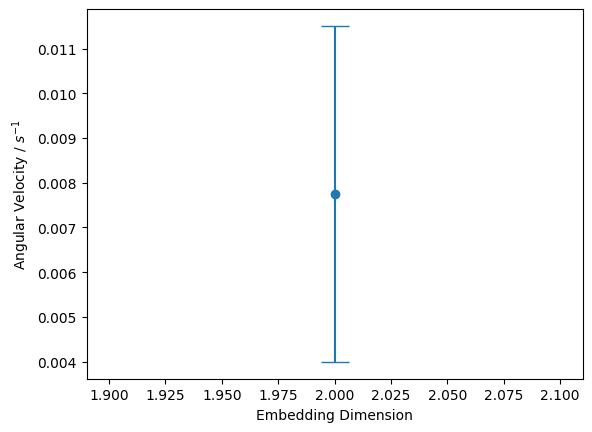

In [18]:
plt.errorbar(
    vision_sizes, 
    [speeds[item].data / 2 for item in vision_sizes],
    yerr = [speeds[item].uncertainty / 2 for item in vision_sizes],
    marker = "o",
    ls = "none",
    capsize=10
)
plt.xlabel("Embedding Dimension")
plt.ylabel(r"Angular Velocity / $s^{-1}$")
plt.show()

## Colloid Accumulation

* Plot 2d histograms of colloids on rod

## Vision Interpretation

* Plot policy surfaces
* Symbolic regression on vision
    - Regression on both colloid and rod and then sum
    - Can you do regression on the sum?

In [7]:
class ColloidEmbedding(nn.Module):
    @nn.compact
    def __call__(self, x):
        return nn.Dense(features=2)(x)
    
class RodEmbedding(nn.Module):
    @nn.compact
    def __call__(self, x):
        return nn.Dense(features=2)(x)
    
class ActorNet(nn.Module):
    """A simple dense model."""
    
    def setup(self):
        self.colloid_embedding = ColloidEmbedding()
        self.rod_embeding = RodEmbedding()
    
    @nn.compact
    def __call__(self, x):
        colloid_embedding = self.colloid_embedding(x[:, 0])
        rod_embedding = self.rod_embeding(x[:, 1])
        
        x = colloid_embedding + rod_embedding
        x = nn.relu(x)
        x = nn.Dense(features=128)(x)
        x = nn.relu(x)
        x = nn.Dense(features=128)(x)
        x = nn.relu(x)
        x = nn.Dense(features=4)(x)
        return colloid_embedding, rod_embedding, jax.nn.softmax(x)

In [35]:
colloid_model = ActorNet()

In [36]:
min_colloid_distance = 2.14 * 2
max_distance = 100.0
min_rod_distance = 2.14 + 100 / 59

In [37]:
colloid_cone_values = onp.random.uniform(
    low=1 / max_distance, 
    high = 1 / min_colloid_distance, 
    size=(500, 5)
) * np.array([1., 0., 0., 0., 0.])
rod_cone_values = onp.random.uniform(
    low=1 / max_distance, 
    high = 1 / min_rod_distance, 
    size=(500, 5)
)

In [38]:
vision_cones = np.stack((colloid_cone_values, rod_cone_values), axis=-1)

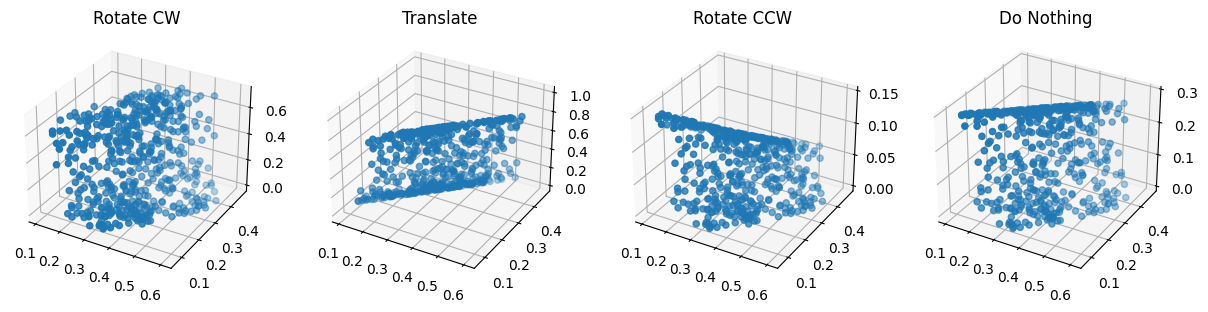

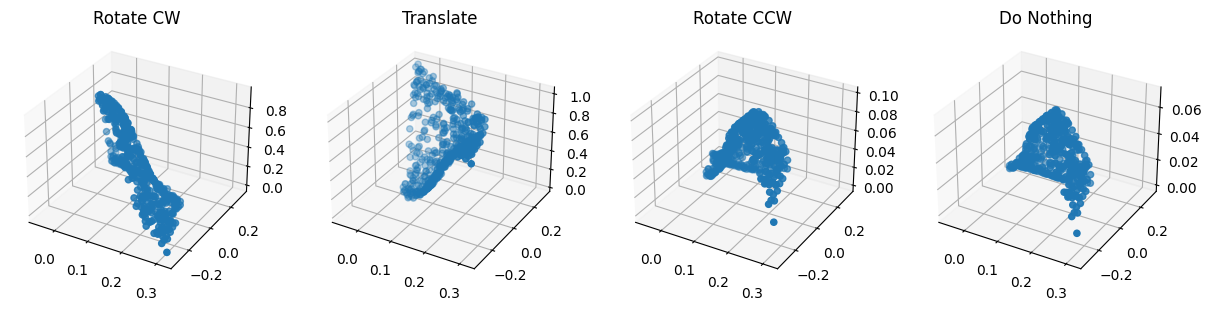

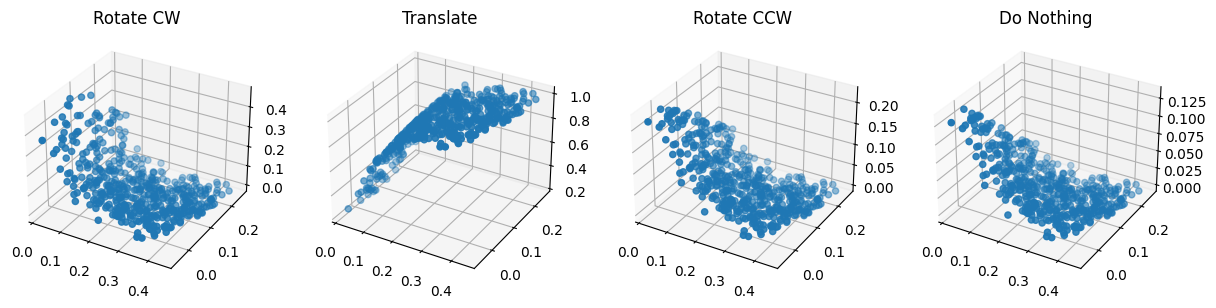

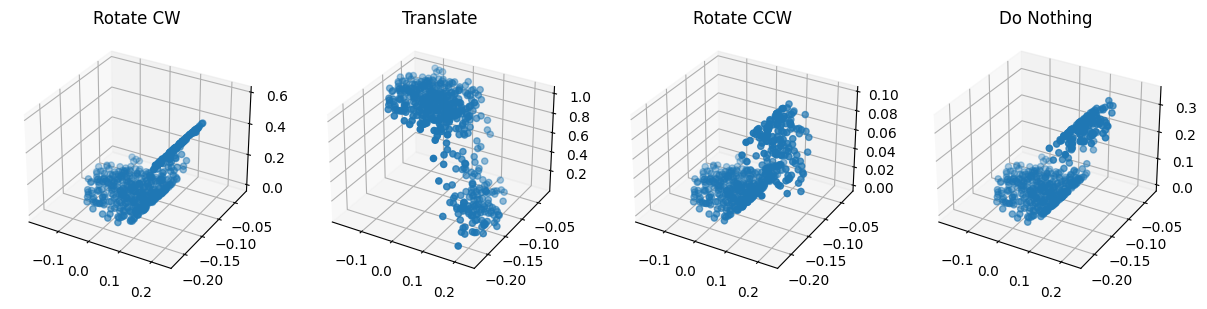

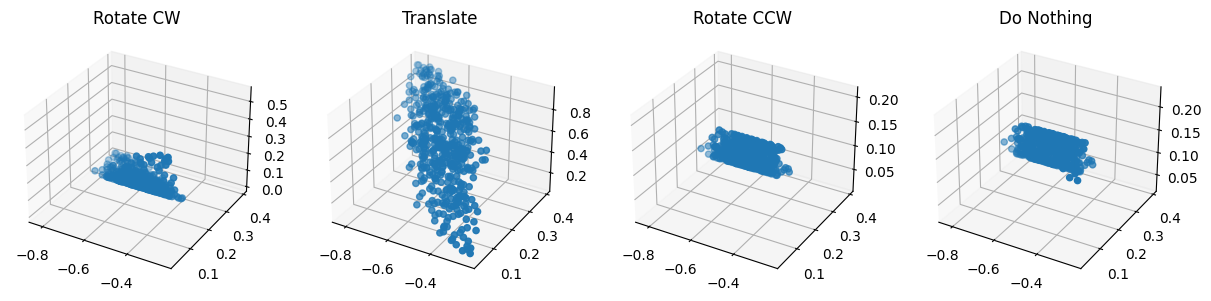

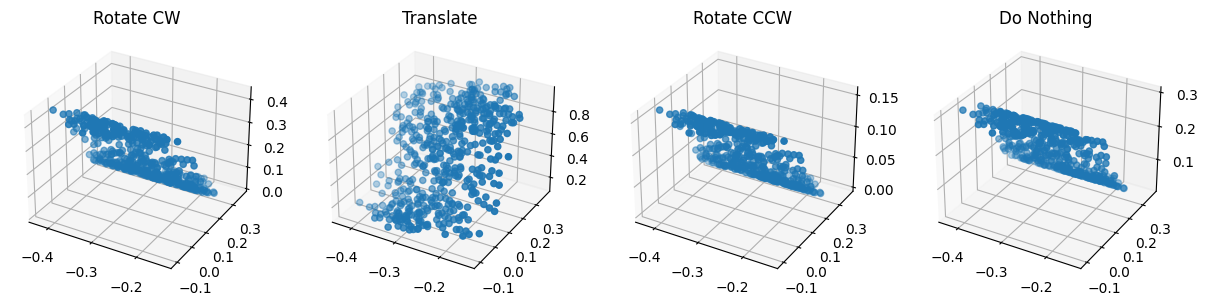

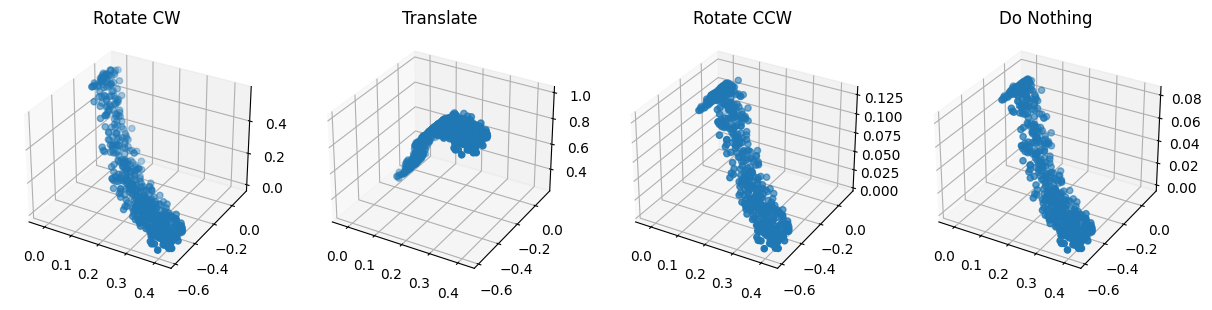

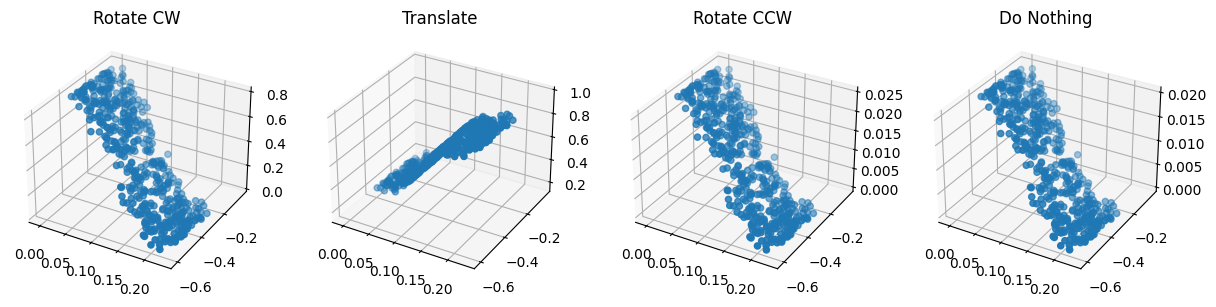

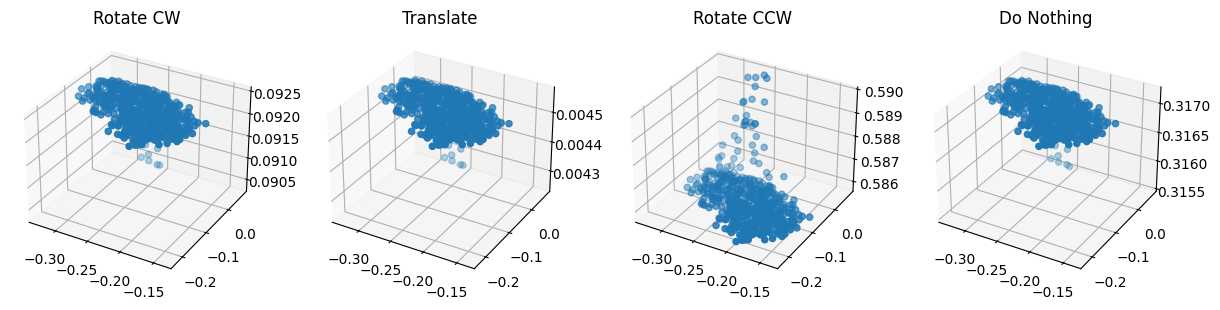

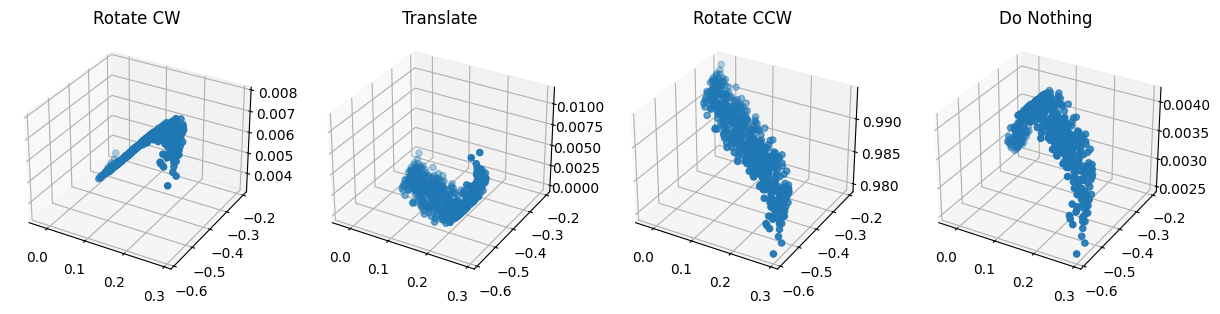

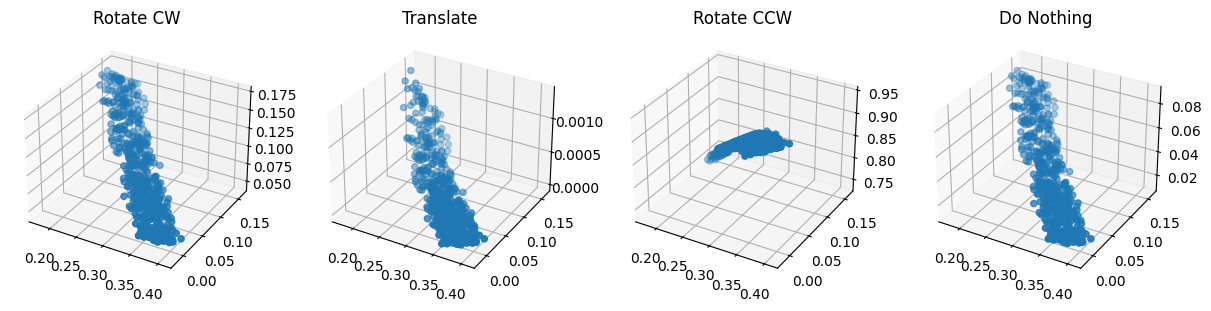

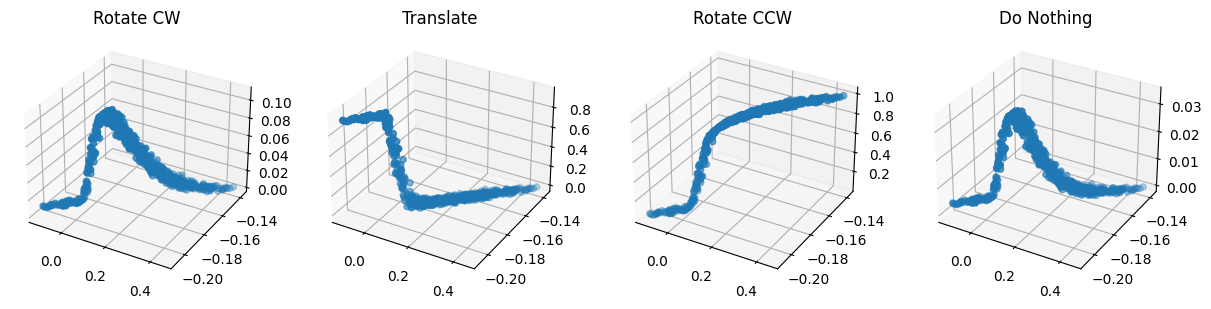

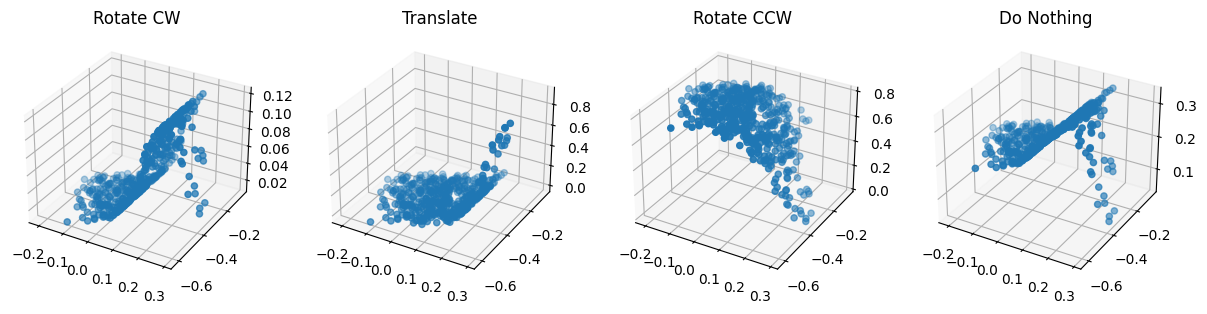

In [39]:
all_probs = []
total_embedding = np.zeros((2,))

for ensemble in good_models:

    parameters = np.load(f"2_dimensions/{ensemble}/Models/ActorModel_0.pkl", allow_pickle=True)[0]


    colloid_embedding, rod_embedding, pre_probs = colloid_model.apply(
        {"params": parameters}, vision_cones
    )
    probs = pre_probs
    all_probs.append(pre_probs)
    total_embedding = colloid_embedding + rod_embedding
    
    fig, ax = plt.subplots(1, 4, figsize=(15, 20), subplot_kw={"projection": '3d'})

    ax[0].scatter(total_embedding[:, 0], total_embedding[:, 1], probs[:, 0])
    ax[1].scatter(total_embedding[:, 0], total_embedding[:, 1], probs[:, 1])
    ax[2].scatter(total_embedding[:, 0], total_embedding[:, 1], probs[:, 2])
    ax[3].scatter(total_embedding[:, 0], total_embedding[:, 1], probs[:, 3])


    ax[0].set_title("Rotate CW")
    ax[1].set_title("Translate")
    ax[2].set_title("Rotate CCW")
    ax[3].set_title("Do Nothing")

    plt.show()


<BarContainer object of 4 artists>

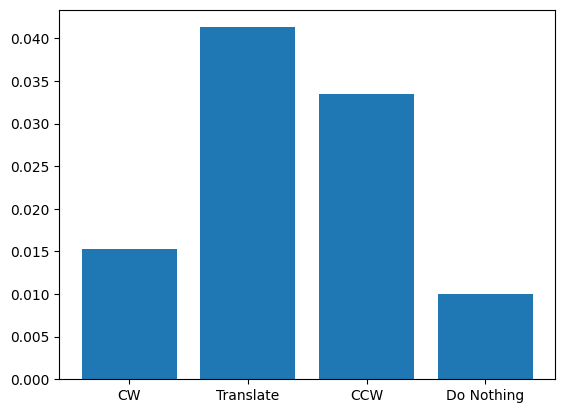

In [40]:
x = ["CW", "Translate", "CCW", "Do Nothing"]
y = onp.sum(all_probs, axis=0).sum(axis=0) / (13 * 5000)

plt.bar(x, y)

## Policy Surfaces

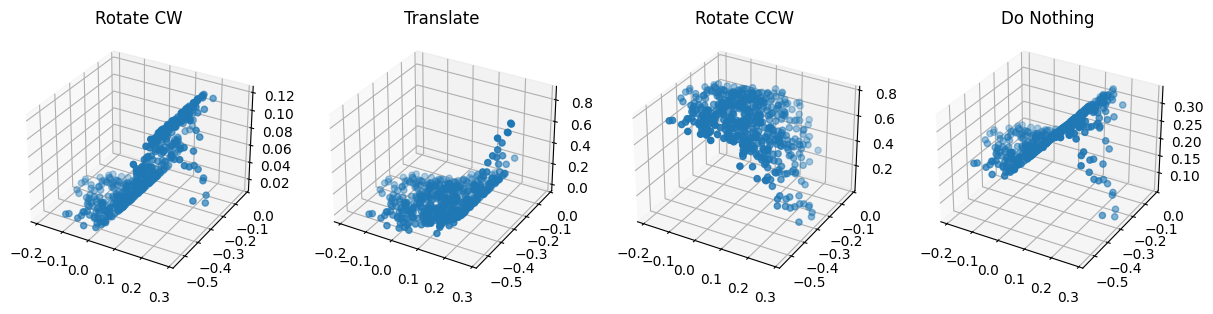

In [26]:
fig, ax = plt.subplots(1, 4, figsize=(15, 20), subplot_kw={"projection": '3d'})

ax[0].scatter(total_embedding[:, 0], total_embedding[:, 1], probs[:, 0])
ax[1].scatter(total_embedding[:, 0], total_embedding[:, 1], probs[:, 1])
ax[2].scatter(total_embedding[:, 0], total_embedding[:, 1], probs[:, 2])
ax[3].scatter(total_embedding[:, 0], total_embedding[:, 1], probs[:, 3])


ax[0].set_title("Rotate CW")
ax[1].set_title("Translate")
ax[2].set_title("Rotate CCW")
ax[3].set_title("Do Nothing")

plt.show()

## Expression Fits

In [42]:
colloid_model = PySRRegressor(
    niterations=40,  # < Increase me for better results
    binary_operators=["+", "*", "-", "/"],
    unary_operators=[
        "cos",
        "exp",
        "sin",
    ]
)

rod_model = PySRRegressor(
    niterations=40,  # < Increase me for better results
    binary_operators=["+", "*", "-", "/"],
    unary_operators=[
        "cos",
        "exp",
        "sin",
    ]
)

In [43]:
colloid_model.fit(rod_cone_values, colloid_embedding)

/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/pysr/sr.py:1296: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Started!

Expressions evaluated per second: 1.090e+05
Head worker occupation: 3.5%
Progress: 234 / 1200 total iterations (19.500%)
Best equations for output 1
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           4.293e-03  4.338e-07  -0.061438993
3           3.620e-03  8.528e-02  (-0.19599605 + x0)
4           3.574e-03  1.262e-02  (-0.19492765 + sin(x0))
5           2.674e-03  2.901e-01  ((0.5732108 * x0) - 0.13796002)
6           2.673e-03  2.680e-04  ((0.5732108 * sin(x0)) - 0.13796002)
7           2.673e-03  2.402e-05  (sin(0.5732108 * sin(x0)) - 0.13796002)
9           2.673e-03  1.457e-04  (((0.5732108 + (x2 * x3)) * x0) - 0.13796002)
11          2.671e-03  2.826e-04  (((0.5732108 + ((x2 * x3) * x2)) * x0) - 0.13796002)
13          2.670e-03  1.438e-04  (((0.5732108 + (((x2 + x0) * x3) * x2)) * x0) - 0.13796002)
14          2.664e-03  2.537e-03  (((0.5732108 + (((sin

PySRRegressor.equations_ = [
[
	    pick         score                                           equation  \
	0         0.000000e+00                                       -0.061438993   
	1         2.329423e-07                                   sin(-0.06146227)   
	2         1.705937e-01                                   (x0 - 0.1956626)   
	3         1.258661e-02                             (sin(x0) - 0.19492741)   
	4   >>>>  2.902903e-01                    ((x0 * 0.56653196) - 0.1374831)   
	5         1.245505e-04               ((0.5732108 * sin(x0)) - 0.13796002)   
	6         4.640403e-04                 ((cos(cos(x1)) * x0) - 0.13526872)   
	7         1.412415e-04        (((0.5732108 * x0) - 0.13796002) * cos(x3))   
	8         2.186096e-03            ((cos(cos(x3 + x2)) * x0) - 0.13796002)   
	9         4.098370e-04       ((cos(cos(x3 + x2)) * sin(x0)) - 0.13796002)   
	10        1.343089e-03  (((0.5732108 - ((x4 - x2) * x3)) * x0) - 0.137...   
	11        3.100062e-04  (((0.5732108 - ((x4 - x2) * x3)) * sin(x0)) - ...   
	12        1.460716e-03  (((0.5732108 - (((x0 - x1) - x2) * x3)) * x0) ...   
	13        3.170321e-04  (sin((0.5732108 - (((x0 - x1) - x2) * x3)) * x...   
	14        1.271397e-03  (((0.5732108 - (((x0 - x1) - (x2 - x4)) * x3))...   
	15        3.977605e-05  (((0.5732108 - (((x0 - x1) - (x2 - sin(x4))) *...   
	16        3.599318e-03  sin((cos(cos(sin(sin(sin(x2 * ((0.13526872 - x...   
	17        1.633759e-03  sin((cos(cos(sin(sin(sin((x2 * ((0.13526872 - ...   
	
	        loss  complexity  
	0   0.004293           1  
	1   0.004293           2  
	2   0.003620           3  
	3   0.003574           4  
	4   0.002674           5  
	5   0.002673           6  
	6   0.002672           7  
	7   0.002672           8  
	8   0.002666           9  
	9   0.002665          10  
	10  0.002661          11  
	11  0.002661          12  
	12  0.002657          13  
	13  0.002656          14  
	14  0.002652          15  
	15  0.002652          16  
	16  0.002643          17  
	17  0.002634          19  
], [
	    pick         score                                           equation  \
	0         0.000000e+00                                        -0.32549083   
	1         2.077032e-07                                    cos(-1.9023327)   
	2   >>>>  1.427837e+00                                 (-0.19126579 - x0)   
	3         1.015588e-01                              (0.8210412 - exp(x0))   
	4         1.681899e-02                   ((-1.2261645 * x0) - 0.16090834)   
	5         2.437224e-08           (((x0 * -0.22616416) - 0.16090836) - x0)   
	6         6.951430e-04        (((-1.245626 * cos(x1)) * x0) - 0.15971723)   
	7         4.480415e-03     (((-1.2472444 + (x3 * x2)) * x0) - 0.16057992)   
	8         2.969445e-03  (((((x1 * x2) * x3) - x0) - 0.133845) / 0.8158...   
	9         1.463196e-03  ((-1.2261645 * (x0 - ((x2 * (x3 - x4)) * x2)))...   
	10        5.447746e-05  ((-1.2261645 * (x0 - ((x2 * (x3 - sin(x4))) * ...   
	11        6.250717e-04  ((-1.2261645 * (x0 - ((x2 * ((1.0681163 * x3) ...   
	12        1.705356e-03  ((-1.2261645 * (x0 - (((x2 / 0.6430981) * (x3 ...   
	13        1.858209e-05  ((-1.2261645 * (x0 - (((sin(x2) / 0.6430981) *...   
	14        1.823377e-04  ((-1.2261645 * (x0 - sin(((x2 * (x3 + (sin(-1....   
	
	        loss  complexity  
	0   0.009629           1  
	1   0.009629           2  
	2   0.002309           3  
	3   0.002086           4  
	4   0.002052           5  
	5   0.002052           7  
	6   0.002050           8  
	7   0.002041           9  
	8   0.002029          11  
	9   0.002023          13  
	10  0.002023          14  
	11  0.002022          15  
	12  0.002018          16  
	13  0.002018          17  
	14  0.002017          20  
]]

In [46]:
colloid_model.latex()[0]

'0.567 x_{0} - 0.137'

In [47]:
colloid_model.latex()[1]

'- x_{0} - 0.191'